# Fase 2 - _Ex Post_

## Tratamento dos dados

Vou preparar os datasets da mesma forma que na fase 1

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

In [97]:
markers = pd.read_csv("./data/marcacoes.csv")
proxies = pd.read_csv("./data/proxies.csv")

markers['data'] = pd.to_datetime(markers['data'])
proxies['data'] = pd.to_datetime(proxies['data'])
markers = markers.set_index("data").sort_index()
proxies = proxies.set_index("data").sort_index()


returns = proxies.pct_change().dropna()
avg_returns = returns.mean(axis=1)
log_returns = np.log(1 + avg_returns).to_frame('MEAN')

T_10 = markers[markers['marcacao'] == 'M10'].index[0]
T_11 = markers[markers['marcacao'] == 'M11'].index[0]

M_10 = markers.loc[T_10, 'valor']
M_11 = markers.loc[T_11, 'valor']

# Capturando período de interesse
log_returns_after_m10 = log_returns.loc[T_10:].iloc[1:]



## O fator de drift

A partir do modelo que tínhamos antes (que considerava o retorno acumulado dos proxies ao longo do intervalo), podemos levar em conta os dados reais que temos como referência. Para isso, vamos retomar a fórmula de predição *Ex Ante* usada anteriormente:

$$
\hat{M}_t = M_{10} \cdot \exp\left\{\sum_{i = (T_{10} + 1)}^{t} r_i\right\}
$$

Para todo $T_{10} < t \le T_{11}$, e $r_i$ é o log-retorno médio no tempo $t = i$.

Considerando a estimativa para $M_{11}$ temos:

$$
\hat{M}_{11} = M_{10} \cdot \exp\left\{\sum_{i = (T_{10} + 1)}^{T_{11}} r_i \right\}
$$

Queremos igualar $\hat{M}_{11}$ a $M_{11}$, e para isso iremos modificar cada uma dos log-retornos acrescentando um fator constante $\alpha$, de forma que temos $r_i^* = r_i + \alpha $ :

$$
\begin{aligned}
M_{11} &= M_{10} \cdot \exp\left\{\sum_{i = (T_{10} + 1)}^{T_{11}} r_i^* \right\} \\[10pt]
\frac{M_{11}}{M_{10}} &= \exp\left\{\sum_{i = (T_{10} + 1)}^{T_{11}} r_i^* \right\} \\[10pt]
\ln\left(\frac{M_{11}}{M_{10}}\right) &= \sum_{i = (T_{10} + 1)}^{T_{11}} r_i^* = \sum_{i = (T_{10} + 1)}^{T_{11}} (r_i + \alpha) \\[10pt]
\end{aligned}
\\[10pt]
$$

Tome $N$ é o número de dias úteis depois de $T_{10}$ até $T_{11}$, então:

$$
\begin{aligned}
\ln\left(\frac{M_{11}}{M_{10}}\right) &= \sum_{i = (T_{10} + 1)}^{T_{11}} (r_i + \alpha) \\[10pt]
&= \alpha \cdot N + \sum_{i = (T_{10} + 1)}^{T_{11}} r_i \\[10pt]
\end{aligned}
$$

Temos, portanto, que:

$$
\alpha = \frac{\ln\left(\frac{M_{11}}{M_{10}}\right) - \sum_{i = (T_{10} + 1)}^{T_{11}} r_i}{N}
$$

### Implementação do modelo de Drift

O primeiro passo é obter o valor de $N$. Não podemos subtrair diretamente $T_{11}$ de $T_{10}$, pois os log-retornos são registrados apenas em dias úteis. Será feito da seguinte forma:

In [98]:
N = log_returns_after_m10.count()

### Obtendo os valores de $r_i^*$

Antes, vamos declarar o valor de $\alpha$, e depois vamos somar ele aos valores dos log-retornos. Após isso, vou criar a tabela com os valores acumulados para cada dia:


In [99]:
alpha = (np.log(M_11 / M_10) - np.sum(log_returns_after_m10)) / N

r_star = (log_returns_after_m10 + alpha).copy()

cumsum_r_star = r_star.cumsum()

print(f"Valor de alpha: {alpha.item():.6f}")


Valor de alpha: -0.003471


### Novas estimativas

Agora, adotando oficialmente os novos log-retornos, podemos estimar novamente os valores intermediários a $M_{10}$ e $M_{11}$:

$$
\hat{M}_t^* = M_{10} \cdot \exp\left\{\sum_{i = (T_{10} + 1)}^{t} (r_i + \alpha)\right\}
$$

In [100]:
ex_post_estimates = M_10 * np.exp(cumsum_r_star)
ex_post_estimates.columns = ['MARKER_ESTIMATE']

ex_post_estimates

,MARKER_ESTIMATE
data,
2025-12-31,391.416391
2026-01-01,398.075749
2026-01-02,398.137123
2026-01-05,398.202683
2026-01-06,386.847258
...,...
2026-06-24,331.695670
2026-06-25,329.910040
2026-06-26,326.145585


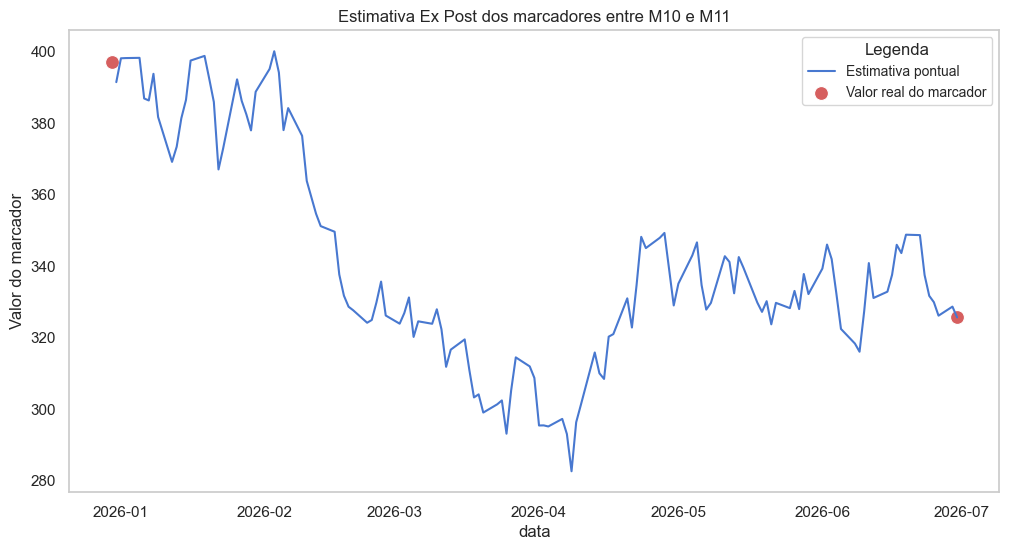

In [101]:
plt.figure(figsize=(12,6))
sns.lineplot(data=ex_post_estimates, x='data', y='MARKER_ESTIMATE', color='b', label='Estimativa pontual')
sns.scatterplot(data=markers.loc[T_10:], x='data', y='valor', color='r', label='Valor real do marcador', s=100)
plt.ylabel('Valor do marcador')
plt.title('Estimativa Ex Post dos marcadores entre M10 e M11')
plt.legend(loc='upper right', fontsize='small', title='Legenda')
plt.grid(False)
plt.show()

### Função interativa para a predição

In [102]:
def return_marker_post_estimate(day:int, month:int, year:int)-> str:

    try:
        date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")

    except Exception as e:
        return "ERRO: Insira uma data válida"


    if date < ex_post_estimates.index.min() or date > ex_post_estimates.index.max():
        return f"ERRO: Insira uma data após o lançamento de M10 ({ex_post_estimates.index.min().strftime('%d/%m/%Y')}) até o dia do lançamento de M11 ({ex_post_estimates.index.max().strftime('%d/%m/%Y')})"

    closest_estimate = float(ex_post_estimates['MARKER_ESTIMATE'].asof(date))

    return f"Valor estimado para {date.strftime('%d/%m/%Y')} : R$ {closest_estimate:.2f}"

In [103]:
day = 30
month = 6
year = 2026


print(return_marker_post_estimate(day, month, year))

Valor estimado para 30/06/2026 : R$ 325.66


In [104]:
M_11_hat = ex_post_estimates['MARKER_ESTIMATE'].asof(T_11)

print(f"Valor real para M_11 ----------- R$ {M_11:.2f}")
print(f"Valor estimado para M_11 ------- R$ {M_11_hat:.2f}" )

Valor real para M_11 ----------- R$ 325.66
Valor estimado para M_11 ------- R$ 325.66


## Comentário sobre resultados

Como se era de esperar, temos que $\hat{M}_{11} = M_{11}$ como gostaríamos. O que aconteceu aqui foi considerar o **retorno real** entre $M_{11}$ e $M_{10}$, e adaptar o retorno total dos proxies a esse retorno real desejado. Isso foi feito adicionando um termo constante $\alpha$ a todos os log-retornos. Podemos obserar no gráfico plotado como isso influenciou negativamente o valor do marcador ao longo do tempo (já que $\alpha \approx -0.003471$), ou seja, a cada dia o retorno do marcador era ligeriamente menor do que o retorno médio das proxies.

In [105]:
ex_post_estimates.to_csv('./data/ex_post_estimates.csv', index=True, header=True, sep=',')